# Accounting-based analysis

In [1]:
import pandas as pd
from accounting_decomp import generate_synthetic_mcd_data, run_accounting_decomp, ac_entity_mix_within_decomp
from accounting_tree_visual import build_sales_decomposition_tree, plot_decomposition_tree

df = generate_synthetic_mcd_data()

In [2]:
display(df)

,week_start,year,week_num,quarter,month,channel,daypart,menu_type,promo_type,gc,...,discount_amount,net_sales,is_offer,is_reward,is_bogo,ac,upt,aur,original_price_per_unit,discount_per_unit
0,2024-01-01,2024,1,1,1,drive_thru,breakfast,core,none,44,...,0.19,311.29,0,0,0,7.074773,1.227273,5.764630,5.768148,0.003519
1,2024-01-01,2024,1,1,1,drive_thru,breakfast,core,offer,5,...,5.68,22.89,1,0,0,4.578000,1.000000,4.578000,5.714000,1.136000
2,2024-01-01,2024,1,1,1,drive_thru,breakfast,core,reward,8,...,5.20,52.59,1,1,0,6.573750,1.250000,5.259000,5.779000,0.520000
3,2024-01-01,2024,1,1,1,drive_thru,breakfast,core,bogo,6,...,8.98,47.31,1,0,1,7.885000,1.666667,4.731000,5.629000,0.898000
4,2024-01-01,2024,1,1,1,drive_thru,breakfast,value,none,33,...,0.00,173.56,0,0,0,5.259394,1.151515,4.567368,4.567368,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20155,2025-12-29,2025,1,4,12,instore,late_night,value,bogo,7,...,10.85,40.28,1,0,1,5.754286,1.428571,4.028000,5.113000,1.085000
20156,2025-12-29,2025,1,4,12,instore,late_night,premium,none,10,...,0.00,139.04,0,0,0,13.904000,1.500000,9.269333,9.269333,0.000000
20157,2025-12-29,2025,1,4,12,instore,late_night,premium,offer,0,...,0.27,18.70,1,0,0,NaN,NaN,9.350000,9.485000,0.135000
20158,2025-12-29,2025,1,4,12,instore,late_night,premium,reward,0,...,0.03,9.54,1,1,0,NaN,NaN,9.540000,9.570000,0.030000


In [3]:
# Show total sales, gc, ac, upt, aur, discount per unit, original price per unit,
# total units, total original price, and total discounts for each year (2024 and 2025) separately

years = [2024, 2025]
summary_rows = []
for year in years:
    df_year = df[df["year"] == year]
    total_sales = df_year["net_sales"].sum()
    total_gc = df_year["gc"].sum()
    total_ac = df_year["ac"].sum()
    total_units = df_year["units"].sum()
    total_original_price = (df_year["original_price_per_unit"] * df_year["units"]).sum()
    total_discount = (df_year["discount_per_unit"] * df_year["units"]).sum()
    avg_upt = total_units / len(df_year) if len(df_year) > 0 else float('nan')
    avg_aur = total_sales / total_units if total_units != 0 else float('nan')
    avg_original_price_per_unit = df_year["original_price_per_unit"].mean()
    avg_discount_per_unit = df_year["discount_per_unit"].mean()

    summary_rows.extend([
        {"Year": year, "Metric": "Total Sales", "Value": total_sales},
        {"Year": year, "Metric": "Total GC", "Value": total_gc},
        {"Year": year, "Metric": "Total AC", "Value": total_ac},
        {"Year": year, "Metric": "Total Units", "Value": total_units},
        {"Year": year, "Metric": "Total Original Price", "Value": total_original_price},
        {"Year": year, "Metric": "Total Discounts", "Value": total_discount},
        {"Year": year, "Metric": "Avg UPT", "Value": avg_upt},
        {"Year": year, "Metric": "Avg AUR", "Value": avg_aur},
        {"Year": year, "Metric": "Avg Original Price per Unit", "Value": avg_original_price_per_unit},
        {"Year": year, "Metric": "Avg Discount per Unit", "Value": avg_discount_per_unit},
    ])

summary_df = pd.DataFrame(summary_rows)

with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(summary_df)

,Year,Metric,Value
0,2024,Total Sales,"759,769.49"
1,2024,Total GC,"84,482.00"
2,2024,Total AC,"79,287.94"
3,2024,Total Units,"119,999.00"
4,2024,Total Original Price,"798,693.79"
5,2024,Total Discounts,"38,924.30"
6,2024,Avg UPT,11.79
7,2024,Avg AUR,6.33
8,2024,Avg Original Price per Unit,6.80
9,2024,Avg Discount per Unit,0.51


# Define decomp structure

In [4]:
# AC panels (in order under AC): UPT×AUR (optional); parallel mix/within panels, one per dimension tuple.
# AC_SHOW_UPT_AUR=False hides UPT/AUR; AC_SHOW_MIX_WITHIN=False hides all mix/within branches.
AC_SHOW_UPT_AUR = True
AC_SHOW_MIX_WITHIN = True
# Under each mix/within panel (e.g. Daypart): False = stop at lunch/dinner/... only; True = also show Mix & Within.
AC_SHOW_MIX_WITHIN_LEAVES = False
AC_MIX_WITHIN_BRANCHES = (("channel",), ("daypart",))  # parallel Channel and Daypart; e.g. only channel: (("channel",),)

_ac_hierarchies = [
    ["channel", "daypart"],
    ["daypart", "channel"],
]
if AC_SHOW_MIX_WITHIN:
    for _branch in AC_MIX_WITHIN_BRANCHES:
        if _branch:
            _h = [_branch[0]]
            if _h not in _ac_hierarchies:
                _ac_hierarchies = [_h] + _ac_hierarchies

outputs = run_accounting_decomp(
    df,
    hierarchy_map={
        "gc": [
            ["is_offer"],
            ["channel", "daypart"],
            ["daypart", "channel"],
        ],
        "sales": [
            ["channel", "daypart"],
            ["daypart", "channel"],
        ],
        "ac": _ac_hierarchies,
        "upt": [
            # ["channel", "daypart"],
            [
             "daypart", 
             "channel"
             ],
            ],
        "aur": [
            ["channel"], 
            ["daypart"]
            ],
        "original_price_per_unit": [
            ["channel"], 
            # ["daypart"]
            ],
        "discount_per_unit": [
            ["channel"], 
            # ["daypart"]
            ],
    },
)



# Generate Tree Map

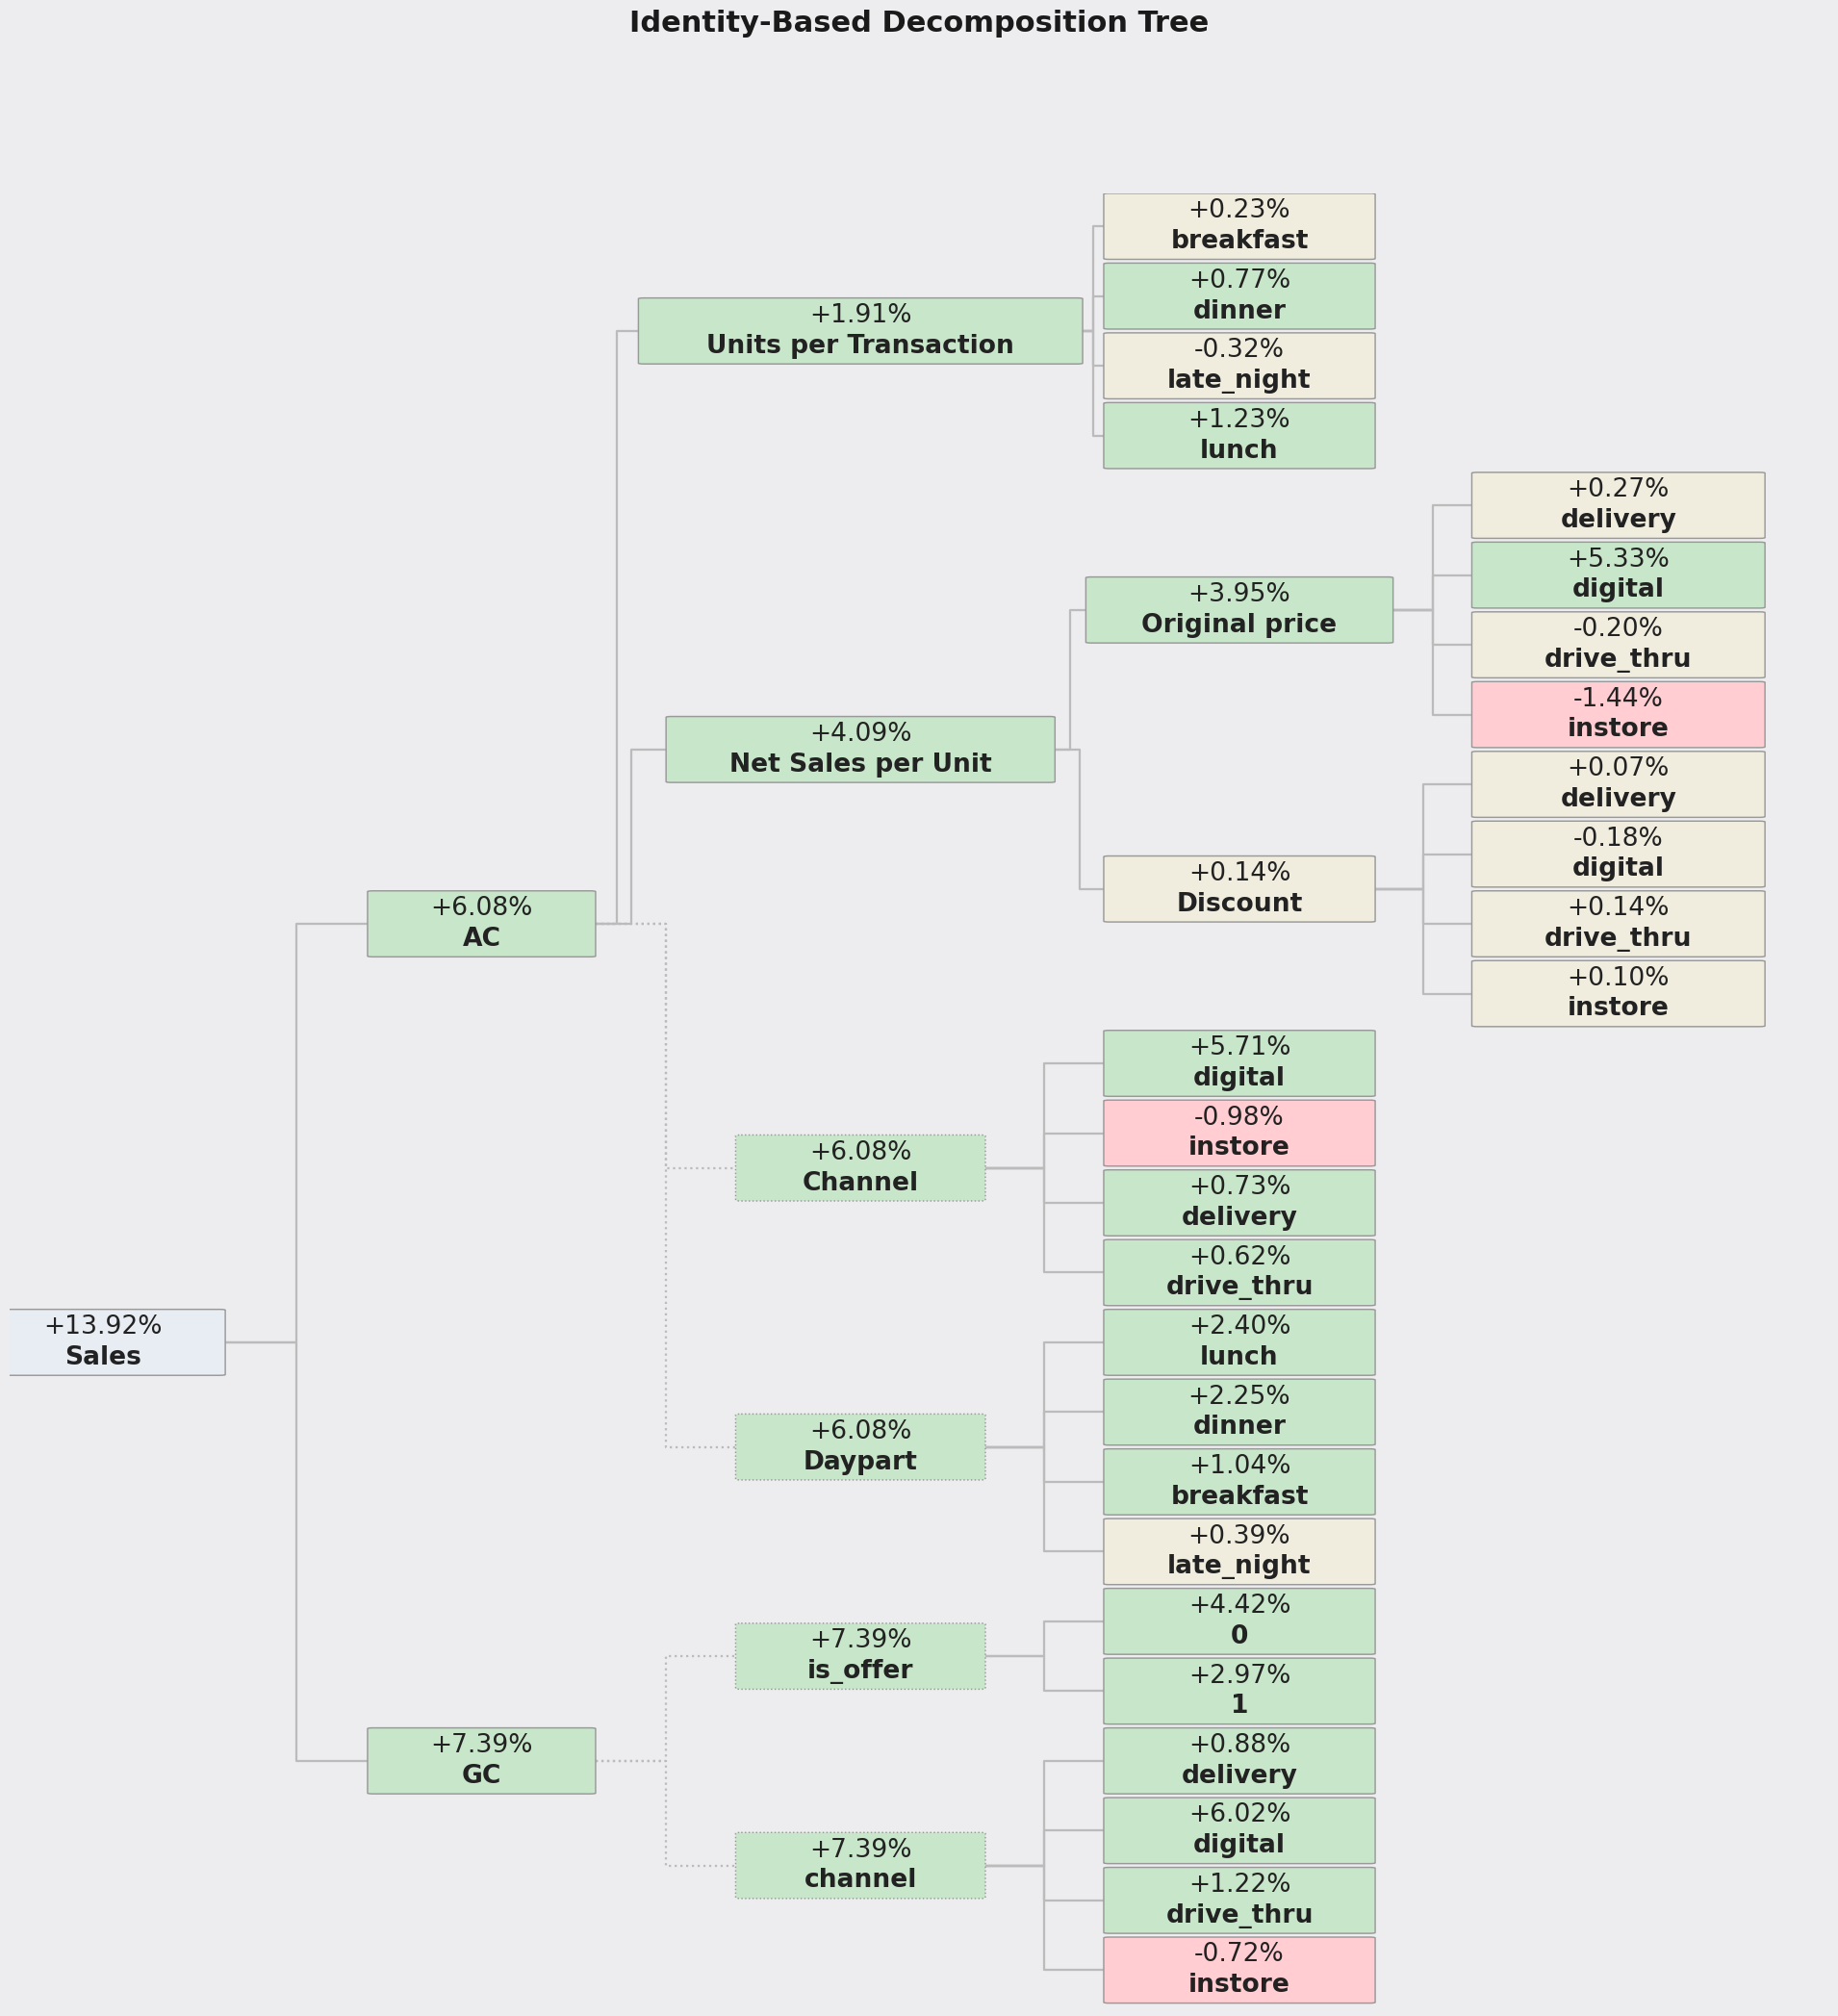

In [5]:

root = build_sales_decomposition_tree(
    df,
    outputs,
    gc_domains=(
        "is_offer", 
        # "daypart", 
        "channel"
                ),   # or ("daypart",) or ("channel",)
    gc_group_labels=True,
    include_interaction = False,
    ac_show_upt_aur=AC_SHOW_UPT_AUR,
    ac_show_mix_within=AC_SHOW_MIX_WITHIN,
    ac_mix_within_branches=AC_MIX_WITHIN_BRANCHES,
    ac_show_mix_within_leaves=AC_SHOW_MIX_WITHIN_LEAVES,
)


# plot_decomposition_tree(root, 
#                         # save_path="sales_decomp_tree.png", 
#                         show=True,
#                         show_meta_lines=False)

plot_decomposition_tree(
    root,
    presentation=True,
    depth_width_factor=0.1,
    leaf_spacing=1.2,          # extra vertical gap (adds on top of auto); try 1.5–2.5 for more air
    min_leaf_edge_gap=0.28,    # minimum gap between box edges; raise if they still feel tight
    level_dx=5.5,
    max_fig_height_inches=48,
                            show=True,
                        show_meta_lines=False)


In [9]:
bridge = outputs["sales_gc_ac_bridge"]
gc_details = outputs["additive__gc"]
ac_details = outputs["ratio__ac"]
upt_df = outputs["ratio__upt"]
aur_df = outputs["ratio__aur"]

gpu_details = outputs["ratio__original_price_per_unit"]
discount_details = outputs["ratio__discount_per_unit"]


In [8]:
print("Keys in outputs dict:")
for key in outputs.keys():
    print(f" - {key}")
print("\nExample shapes/types for selected output keys:")
for key in outputs.keys():
    val = outputs[key]
    if hasattr(val, "shape"):
        print(f"{key}: shape={val.shape}")
    else:
        print(f"{key}: type={type(val)}")

Keys in outputs dict:
 - sales_gc_ac_bridge
 - additive__gc
 - additive__sales
 - ratio__ac
 - ratio__upt
 - ratio__aur
 - ratio__original_price_per_unit
 - ratio__discount_per_unit

Example shapes/types for selected output keys:
sales_gc_ac_bridge: shape=(4, 5)
additive__gc: shape=(45, 20)
additive__sales: shape=(42, 20)
ratio__ac: shape=(42, 30)
ratio__upt: shape=(21, 30)
ratio__aur: shape=(10, 30)
ratio__original_price_per_unit: shape=(5, 30)
ratio__discount_per_unit: shape=(5, 30)


In [10]:
display(bridge)
# display(gc_details)
display(ac_details)
# display(upt_df)
# display(aur_df)
# display(gpu_details)
# display(discount_details)

,component,base_value,current_value,delta_abs,pct_of_base_sales
0,sales_growth_total,759769.490000,865547.340000,105777.850000,0.139224
1,gc_contribution_to_sales,84482.000000,90726.000000,56153.981861,0.073909
2,ac_contribution_to_sales,8.993271,9.540235,46208.624078,0.060819
3,interaction,NaN,NaN,3415.244061,0.004495


,metric_name,analysis_type,metric,numerator_col,denominator_col,hierarchy_name,level,node_dimension,node_value,node_key,...,current_weight_of_root,base_share_within_parent_den,current_share_within_parent_den,mix_abs_root,within_abs_root,total_abs_root,mix_pct_of_root_metric,within_pct_of_root_metric,total_pct_of_root_metric,calc_formula
0,ac,ratio,ac,net_sales,gc,channel > daypart,0,ROOT,ALL,ROOT,...,1.000000,1.000000,1.000000,0.000000,0.546964,0.546964,0.000000,0.060819,0.060819,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
1,ac,ratio,ac,net_sales,gc,channel > daypart,1,channel,delivery,channel=delivery,...,0.165520,0.168995,0.165520,-0.037258,0.103002,0.065744,-0.004143,0.011453,0.007310,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
2,ac,ratio,ac,net_sales,gc,channel > daypart,1,channel,digital,channel=digital,...,0.281110,0.241720,0.281110,0.350386,0.163294,0.513680,0.038961,0.018157,0.057118,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
3,ac,ratio,ac,net_sales,gc,channel > daypart,1,channel,drive_thru,channel=drive_thru,...,0.361693,0.376246,0.361693,-0.125127,0.180879,0.055752,-0.013913,0.020113,0.006199,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
4,ac,ratio,ac,net_sales,gc,channel > daypart,1,channel,instore,channel=instore,...,0.191676,0.213039,0.191676,-0.180068,0.091857,-0.088212,-0.020023,0.010214,-0.009809,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
5,ac,ratio,ac,net_sales,gc,channel > daypart,2,daypart,breakfast,channel=delivery > daypart=breakfast,...,0.039680,0.245500,0.239728,-0.016419,0.019176,0.002757,-0.001826,0.002132,0.000307,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
6,ac,ratio,ac,net_sales,gc,channel > daypart,2,daypart,dinner,channel=delivery > daypart=dinner,...,0.052598,0.324228,0.317773,-0.026776,0.035114,0.008338,-0.002977,0.003905,0.000927,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
7,ac,ratio,ac,net_sales,gc,channel > daypart,2,daypart,late_night,channel=delivery > daypart=late_night,...,0.022463,0.134272,0.135713,-0.002562,0.016983,0.014421,-0.000285,0.001888,0.001604,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
8,ac,ratio,ac,net_sales,gc,channel > daypart,2,daypart,lunch,channel=delivery > daypart=lunch,...,0.050779,0.296001,0.306786,0.007748,0.032480,0.040228,0.000862,0.003612,0.004473,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
9,ac,ratio,ac,net_sales,gc,channel > daypart,2,daypart,breakfast,channel=digital > daypart=breakfast,...,0.068183,0.247245,0.242550,0.063351,0.036092,0.099443,0.007044,0.004013,0.011058,total_abs_root = (w1-w0)*ratio_base + w1*(rati...


In [17]:
from IPython.display import display
pd.set_option('display.max_columns', None)
display(aur_df)

,metric_name,analysis_type,metric,numerator_col,denominator_col,hierarchy_name,level,node_dimension,node_value,node_key,parent_key,path,base_numerator,current_numerator,base_denominator,current_denominator,ratio_base,ratio_current,ratio_delta,base_weight_of_root,current_weight_of_root,base_share_within_parent_den,current_share_within_parent_den,mix_abs_root,within_abs_root,total_abs_root,mix_pct_of_root_metric,within_pct_of_root_metric,total_pct_of_root_metric,calc_formula
0,aur,ratio,aur,net_sales,units,channel,0,ROOT,ALL,ROOT,None,ROOT,759769.49,865547.34,119999,131333,6.331465,6.590479,0.259014,1.000000,1.000000,1.000000,1.000000,0.000000,0.259014,0.259014,0.000000,0.040909,0.040909,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
1,aur,ratio,aur,net_sales,units,channel,1,channel,delivery,channel=delivery,ROOT,channel=delivery,153109.27,170390.14,22026,23568,6.951297,7.229724,0.278427,0.183552,0.179452,0.183552,0.179452,-0.028495,0.049964,0.021469,-0.004501,0.007891,0.003391,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
2,aur,ratio,aur,net_sales,units,channel,1,channel,digital,channel=digital,ROOT,channel=digital,181650.67,241680.46,29229,37127,6.214741,6.509561,0.294820,0.243577,0.282694,0.243577,0.282694,0.243099,0.083344,0.326443,0.038395,0.013163,0.051559,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
3,aur,ratio,aur,net_sales,units,channel,1,channel,drive_thru,channel=drive_thru,ROOT,channel=drive_thru,273307.92,298566.04,44183,46463,6.185816,6.425888,0.240072,0.368195,0.353780,0.368195,0.353780,-0.089166,0.084933,-0.004234,-0.014083,0.013414,-0.000669,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
4,aur,ratio,aur,net_sales,units,channel,1,channel,instore,channel=instore,ROOT,channel=instore,151701.63,154910.70,24561,24175,6.176525,6.407888,0.231363,0.204677,0.184074,0.204677,0.184074,-0.127253,0.042588,-0.084665,-0.020098,0.006726,-0.013372,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
5,aur,ratio,aur,net_sales,units,daypart,0,ROOT,ALL,ROOT,None,ROOT,759769.49,865547.34,119999,131333,6.331465,6.590479,0.259014,1.000000,1.000000,1.000000,1.000000,0.000000,0.259014,0.259014,0.000000,0.040909,0.040909,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
6,aur,ratio,aur,net_sales,units,daypart,1,daypart,breakfast,daypart=breakfast,ROOT,daypart=breakfast,158151.32,178333.60,27683,30029,5.712940,5.938713,0.225773,0.230694,0.228648,0.230694,0.228648,-0.011688,0.051622,0.039935,-0.001846,0.008153,0.006307,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
7,aur,ratio,aur,net_sales,units,daypart,1,daypart,dinner,daypart=dinner,ROOT,daypart=dinner,287169.69,326788.43,41961,46057,6.843728,7.095304,0.251576,0.349678,0.350689,0.349678,0.350689,0.006918,0.088225,0.095142,0.001093,0.013934,0.015027,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
8,aur,ratio,aur,net_sales,units,daypart,1,daypart,late_night,daypart=late_night,ROOT,daypart=late_night,99812.26,110381.29,15550,16286,6.418795,6.777680,0.358885,0.129584,0.124005,0.129584,0.124005,-0.035811,0.044504,0.008693,-0.005656,0.007029,0.001373,total_abs_root = (w1-w0)*ratio_base + w1*(rati...
9,aur,ratio,aur,net_sales,units,daypart,1,daypart,lunch,daypart=lunch,ROOT,daypart=lunch,214636.22,250044.02,34805,38961,6.166821,6.417803,0.250981,0.290044,0.296658,0.290044,0.296658,0.040788,0.074456,0.115243,0.006442,0.011760,0.018202,total_abs_root = (w1-w0)*ratio_base + w1*(rati...


In [3]:
upt_df = outputs["ratio__upt"]
aur_df = outputs["ratio__aur"]
gpu_details = outputs["ratio__original_price_per_unit"]
discount_details = outputs["ratio__discount_per_unit"]

# upt_detail = upt_df[
#     (upt_df["hierarchy_name"] == "promo_type > channel") &
#     (upt_df["level"] == 2)
# ].copy()

# upt_detail = upt_detail.sort_values("total_pct_of_root_metric", ascending=False)

# print(upt_detail[
#     [
#         "path",
#         "ratio_base",
#         "ratio_current",
#         "mix_pct_of_root_metric",
#         "within_pct_of_root_metric",
#         "total_pct_of_root_metric",
#     ]
# ])